#SEMMA(Sample, Explore, Modify, Model, Assess)

##1. Sample

In [1]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/kaggle/train.csv')

# Take a random sample (optional, if you want to work with a smaller dataset)
sample_data = data.sample(frac=0.5, random_state=42)

# Display the first few rows of the sample
print(sample_data.head())

# Check for basic statistics
print(sample_data.describe())


     PassengerId  Survived  Pclass  \
709          710         1       3   
439          440         0       2   
840          841         0       3   
720          721         1       2   
39            40         1       3   

                                                  Name     Sex   Age  SibSp  \
709  Moubarek, Master. Halim Gonios ("William George")    male   NaN      1   
439             Kvillner, Mr. Johan Henrik Johannesson    male  31.0      0   
840                        Alhomaki, Mr. Ilmari Rudolf    male  20.0      0   
720                  Harper, Miss. Annie Jessie "Nina"  female   6.0      0   
39                         Nicola-Yarred, Miss. Jamila  female  14.0      1   

     Parch            Ticket     Fare Cabin Embarked  
709      1              2661  15.2458   NaN        C  
439      0        C.A. 18723  10.5000   NaN        S  
840      0  SOTON/O2 3101287   7.9250   NaN        S  
720      1            248727  33.0000   NaN        S  
39       0           

##2. Explore

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             90
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          343
Embarked         2
dtype: int64


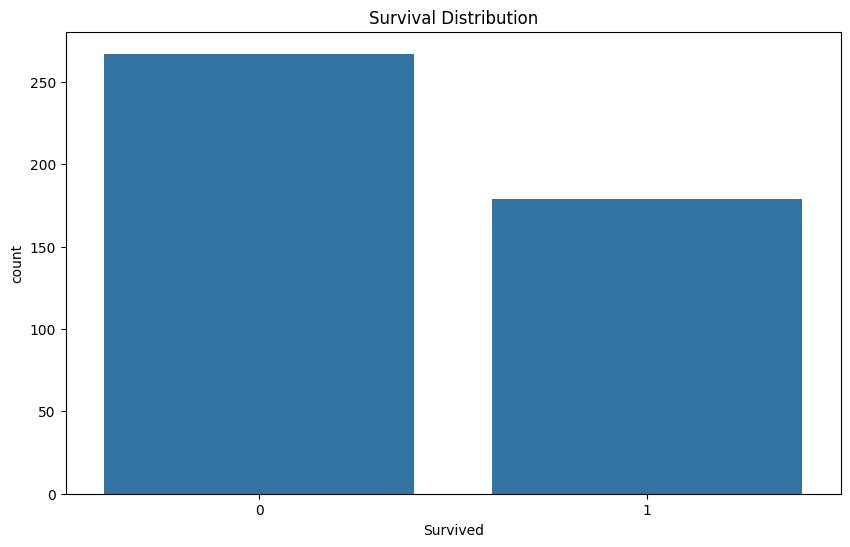

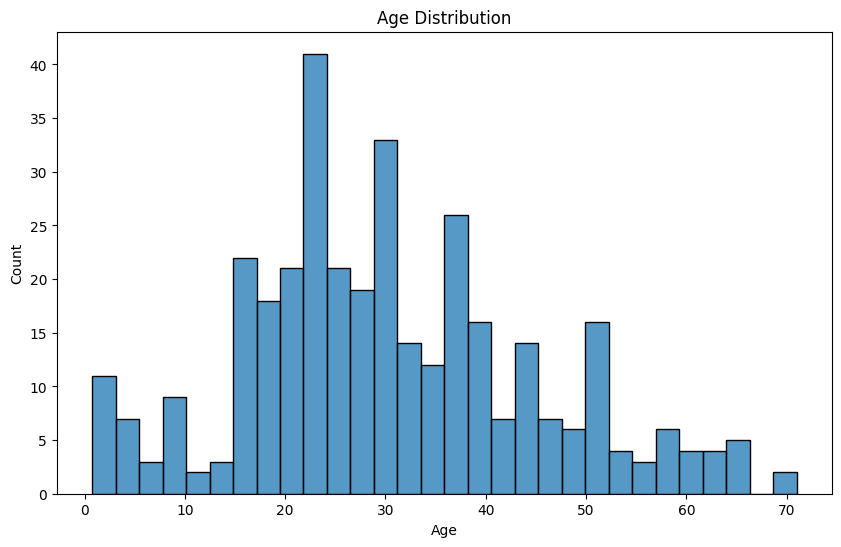

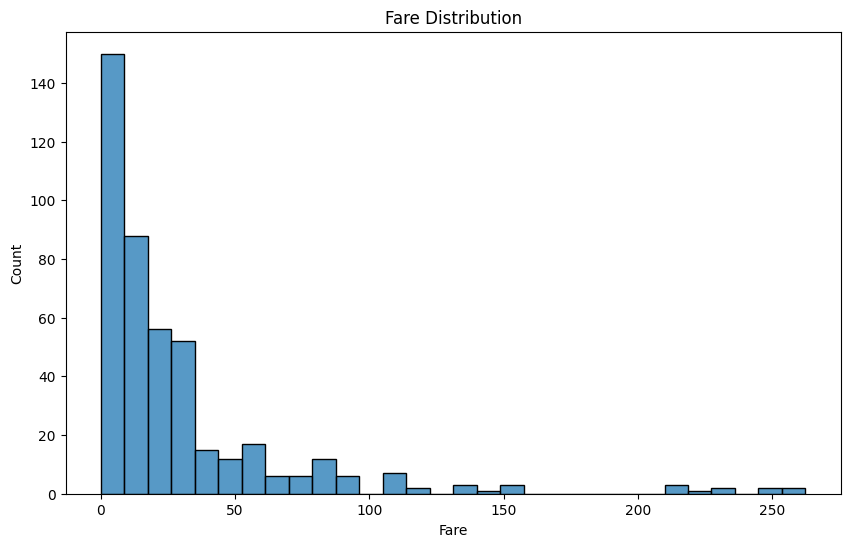

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check for missing values
print(sample_data.isnull().sum())

# Visualize the distribution of survival based on key features
plt.figure(figsize=(10,6))
sns.countplot(x='Survived', data=sample_data)
plt.title('Survival Distribution')
plt.show()

# Explore distribution of Age and Fare
plt.figure(figsize=(10,6))
sns.histplot(sample_data['Age'].dropna(), kde=False, bins=30)
plt.title('Age Distribution')
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(sample_data['Fare'], kde=False, bins=30)
plt.title('Fare Distribution')
plt.show()


##3. Modify

In [3]:
# Fill missing Age values with the median
sample_data['Age'].fillna(sample_data['Age'].median(), inplace=True)

# Fill missing Embarked values with the mode
sample_data['Embarked'].fillna(sample_data['Embarked'].mode()[0], inplace=True)

# Convert categorical variables into numerical (One-Hot Encoding)
sample_data = pd.get_dummies(sample_data, columns=['Sex', 'Embarked'], drop_first=True)

# Drop unnecessary columns
sample_data.drop(columns=['Cabin', 'Ticket', 'Name'], inplace=True)

# Display cleaned data
print(sample_data.info())


<class 'pandas.core.frame.DataFrame'>
Index: 446 entries, 709 to 711
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  446 non-null    int64  
 1   Survived     446 non-null    int64  
 2   Pclass       446 non-null    int64  
 3   Age          446 non-null    float64
 4   SibSp        446 non-null    int64  
 5   Parch        446 non-null    int64  
 6   Fare         446 non-null    float64
 7   Sex_male     446 non-null    bool   
 8   Embarked_Q   446 non-null    bool   
 9   Embarked_S   446 non-null    bool   
dtypes: bool(3), float64(2), int64(5)
memory usage: 29.2 KB
None


<ipython-input-3-edee8314ca21>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sample_data['Age'].fillna(sample_data['Age'].median(), inplace=True)
<ipython-input-3-edee8314ca21>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

##4. Model

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split the data into features (X) and target (y)
X = sample_data.drop(columns=['Survived'])
y = sample_data['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build a logistic regression model
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of the model: {accuracy:.2f}')


Accuracy of the model: 0.79


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##5. Assess

              precision    recall  f1-score   support

           0       0.84      0.80      0.82        80
           1       0.72      0.78      0.75        54

    accuracy                           0.79       134
   macro avg       0.78      0.79      0.79       134
weighted avg       0.79      0.79      0.79       134



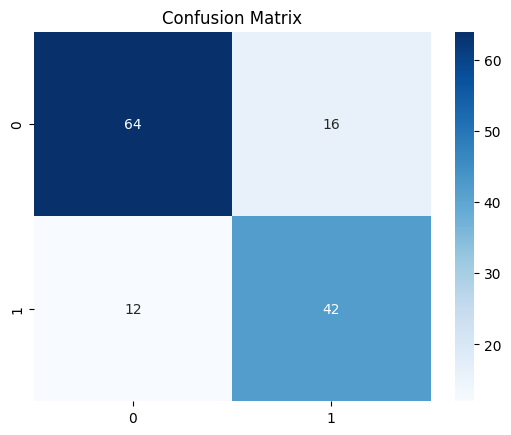

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()
